# Рейтинг жанров по годам

Этот ноутбук показывает, какие жанры получали самую высокую долю положительных отзывов в разные годы. Если у игры несколько жанров, она учитывается в каждом из них, потому что Steam-жанры являются списковым признаком.

## Импорты и настройки

Подключаем финальный датасет и путь для графика. Минимум в 500 отзывов нужен, чтобы жанр не попадал в топ из-за одной небольшой игры с нестабильной оценкой.

In [5]:
from pathlib import Path
import sys

# путь к корню проекта
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# доступ к project_paths из ноутбука
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))


import json

from IPython.display import Image, display
import matplotlib.pyplot as plt
import pandas as pd

from project_paths import STEAM_GAMES_DATASET_CSV_PATH, TOP_GENRES_BY_YEAR_PLOT_PATH

# входной датасет и порог отзывов
DATASET_PATH = STEAM_GAMES_DATASET_CSV_PATH
MIN_TOTAL_REVIEWS = 500

## Чтение и базовая очистка

Загружаем датасет и убираем строки с пропусками. В этом конкретном графике нужны дата релиза, жанры и поля отзывов, поэтому строки с отсутствующими значениями не участвуют в расчете.

In [6]:
def load_dataset(path: str) -> pd.DataFrame:
    # чтение финального csv
    return pd.read_csv(path)


def drop_null_rows(df: pd.DataFrame) -> pd.DataFrame:
    # убираем строки с пропусками
    return df.dropna().copy()


# загружаем датасет
df = load_dataset(DATASET_PATH)
print(f"Загружено строк: {len(df)}")

# оставляем только полные строки
df = drop_null_rows(df)
print(f"Строк после удаления пропусков: {len(df)}")
df.head()

Загружено строк: 38372
Строк после удаления пропусков: 18907


,appid,name,is_free,developers,publishers,price_final,price_currency,windows,mac,linux,categories,genres,release_date,review_score_desc,total_positive,total_negative
0,10,Counter-Strike,False,"[""Valve""]","[""Valve""]",999.0,USD,True,True,True,"[""Multi-player"", ""PvP"", ""Online PvP"", ""Shared/...","[""Action""]",2000-11-01,Overwhelmingly Positive,253209.0,6724.0
1,20,Team Fortress Classic,False,"[""Valve""]","[""Valve""]",499.0,USD,True,True,True,"[""Multi-player"", ""PvP"", ""Online PvP"", ""Shared/...","[""Action""]",1999-04-01,Very Positive,7984.0,1183.0
2,30,Day of Defeat,False,"[""Valve""]","[""Valve""]",499.0,USD,True,True,True,"[""Multi-player"", ""Camera Comfort"", ""Color Alte...","[""Action""]",2003-05-01,Very Positive,6595.0,712.0
3,40,Deathmatch Classic,False,"[""Valve""]","[""Valve""]",499.0,USD,True,True,True,"[""Multi-player"", ""PvP"", ""Online PvP"", ""Shared/...","[""Action""]",2001-06-01,Very Positive,2732.0,554.0
4,50,Half-Life: Opposing Force,False,"[""Gearbox Software""]","[""Valve""]",499.0,USD,True,True,True,"[""Single-player"", ""Multi-player"", ""Custom Volu...","[""Action""]",1999-11-01,Overwhelmingly Positive,26953.0,1314.0


## Подготовка жанров

Жанры лежат в CSV как JSON-строка, поэтому их нужно превратить обратно в список. После этого каждая игра с несколькими жанрами будет размножена на несколько строк: одна строка на один жанр.

In [7]:
def parse_genres(genres_str: str) -> list[str]:
    # жанры из json-строки
    try:
        return json.loads(genres_str)
    except (json.JSONDecodeError, TypeError):
        return []


def compute_top_genres_by_year(df: pd.DataFrame) -> pd.DataFrame:
    # копия, чтобы не менять исходный датафрейм
    df = df.copy()

    # превращаем строку жанров в список
    df["genres_list"] = df["genres"].apply(parse_genres)

    # одна игра с несколькими жанрами становится несколькими строками
    df = df.explode("genres_list")
    df = df.dropna(subset=["genres_list"])

    # год релиза нужен для группировки
    df["year"] = pd.to_datetime(df["release_date"]).dt.year

    # ограничиваем анализ современным периодом
    df = df[(df["year"] >= 2010) & (df["year"] <= 2025)]

    # суммируем отзывы внутри пары год-жанр
    grouped = (
        df.groupby(["year", "genres_list"])
        .agg(
            total_positive=("total_positive", "sum"),
            total_negative=("total_negative", "sum"),
        )
        .reset_index()
    )

    # считаем долю положительных отзывов
    grouped["total_reviews"] = grouped["total_positive"] + grouped["total_negative"]

    # убираем жанры с маленькой базой отзывов
    grouped = grouped[grouped["total_reviews"] >= MIN_TOTAL_REVIEWS].copy()
    grouped["positive_share"] = grouped["total_positive"] / grouped["total_reviews"]

    # выбираем топ-5 жанров внутри каждого года
    top5 = (
        grouped.sort_values(["year", "positive_share"], ascending=[True, False])
        .groupby("year")
        .head(5)
        .reset_index(drop=True)
    )

    return top5


# считаем итоговую таблицу для графика
top5 = compute_top_genres_by_year(df)
print(f"Строк в топе жанров по годам: {len(top5)}")

Строк в топе жанров по годам: 80


Получилось 80 строк: по пять жанров на каждый год с 2010 по 2025. Чаще всего в годовых топах встречаются `Indie` и `Simulation` - по 13 раз, затем `Adventure` - 9 раз. Это не значит, что эти жанры всегда имеют самый высокий рейтинг у каждой отдельной игры; здесь агрегируются отзывы всех игр жанра внутри года.

## График топ-5 жанров по годам

На графике для каждого года показаны пять жанров с максимальной долей положительных отзывов.

Plot saved to C:\Users\User\Desktop\workspaces\SteamAnalytics\SteamParcer\analytics\graphs\top_genres_by_year.png


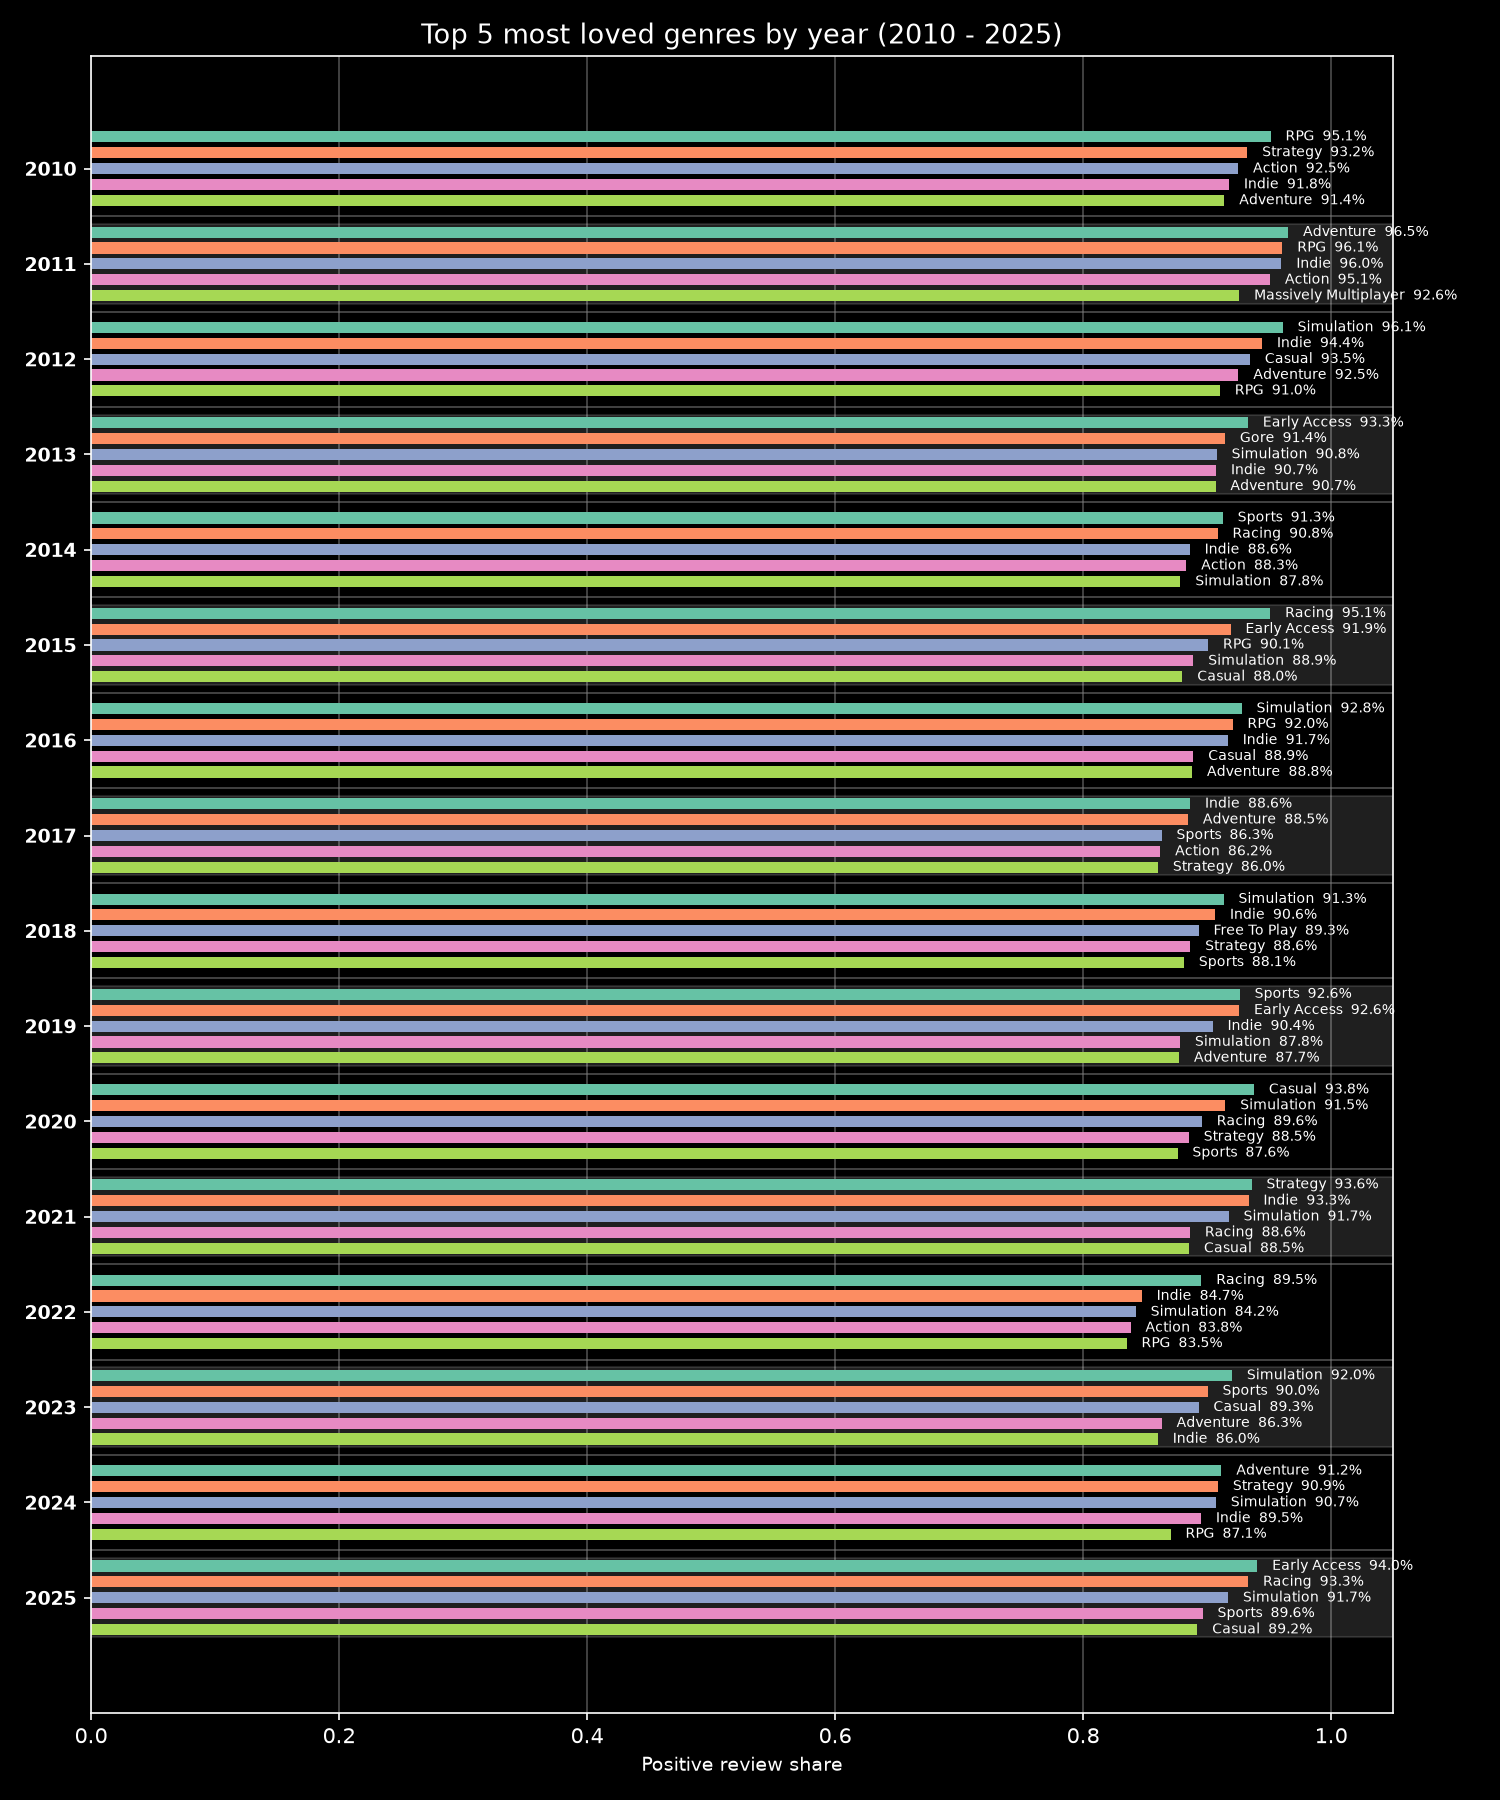

In [8]:
def plot_top_genres(top5: pd.DataFrame) -> None:
    # список годов и палитра баров
    years = sorted(top5["year"].unique())
    colors = plt.cm.Set2.colors

    fig, ax = plt.subplots(figsize=(10, 12))

    # массивы для ручной раскладки баров
    y_pos = []
    genre_labels = []
    values = []
    bar_colors = []
    year_ticks = []
    year_labels = []

    # собираем позиции баров по годовым группам
    current_y = 0
    for year in years:
        year_rows = (
            top5[top5["year"] == year]
            .sort_values("positive_share", ascending=False)
            .head(5)
        )

        start_y = current_y
        for rank, (_, row) in enumerate(year_rows.iterrows()):
            y_pos.append(current_y)
            genre_labels.append(row["genres_list"])
            values.append(row["positive_share"])
            bar_colors.append(colors[rank % len(colors)])
            current_y += 1

        # подпись года ставим по центру группы
        year_ticks.append((start_y + current_y - 1) / 2)
        year_labels.append(str(year))
        current_y += 1

    # основной горизонтальный bar chart
    ax.barh(y_pos, values, height=0.7, color=bar_colors, zorder=2)
    ax.set_yticks(year_ticks)
    ax.set_yticklabels(year_labels, fontsize=9, fontweight="bold")
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)
    ax.grid(axis="x", alpha=0.3, zorder=0)
    ax.set_xlabel("Positive review share", fontsize=9)

    # подписи жанров и процентов рядом с барами
    for y, val, label in zip(y_pos, values, genre_labels):
        ax.text(
            val + 0.012,
            y,
            f"{label}  {val:.1%}",
            va="center",
            fontsize=6.5,
        )

    # разделители между годами
    n_items_per_year = 6
    for i in range(1, len(years)):
        sep = i * n_items_per_year - 1
        ax.axhline(y=sep, color="gray", linewidth=0.8, alpha=0.6)

    # легкая заливка через год для читаемости
    for i in range(len(years)):
        start = i * n_items_per_year
        end = start + 4
        if i % 2 == 1:
            ax.axhspan(
                start - 0.5,
                end + 0.5,
                color="lightgray",
                alpha=0.15,
                zorder=0,
            )

    # сохранение графика
    ax.set_title("Top 5 most loved genres by year (2010 - 2025)", fontsize=13)
    plt.tight_layout()
    TOP_GENRES_BY_YEAR_PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(TOP_GENRES_BY_YEAR_PLOT_PATH, dpi=150)
    print(f"Plot saved to {TOP_GENRES_BY_YEAR_PLOT_PATH}")


# строим и показываем сохраненный png
plot_top_genres(top5)
plt.close("all")
display(Image(filename=str(TOP_GENRES_BY_YEAR_PLOT_PATH)))

График показывает устойчивые жанровые паттерны по годам, но его нужно читать аккуратно: игра с несколькими жанрами учитывается в каждом из них. Жанры не являются независимыми группами и суммы по жанрам не равны числу уникальных игр.